<h1 style="color:#56B4E9;">Week 5 - Day 4</h1>

<h2 style="color:#0072B2;">t-SNE Visualization & Anomaly Detection</h2>

<h3 style="color:#009E73;">Extending the Cleveland Patient-Structure Analysis</h3>

This notebook continues the same Cleveland Heart Disease unsupervised-learning workflow developed during Days 1–3.

The previous analysis established that:

- K-Means divided the patients into two broad profiles, but the Silhouette Score was modest.
- DBSCAN found one connected density region and identified a small set of locally isolated patients.
- Hierarchical clustering also produced two broad branches with considerable overlap.
- PCA provided a transparent global projection, but its first two components retained only part of the total standardized variance.

Day 4 asks two new questions:

1. Can t-SNE reveal local patient neighborhoods that were less visible in the linear PCA projection?
2. Does Isolation Forest identify unusual patients similar to the noise observations found by DBSCAN?

<span style="color:#009E73;"><b>Main goal:</b></span>  
Extend the earlier results instead of starting a separate experiment, while keeping each comparison based on the same patient representation used previously.

<span style="color:#D55E00;"><b>Unsupervised-learning discipline:</b></span>  
The diagnosis variable will not be used to fit PCA, t-SNE, clustering, or Isolation Forest. It may appear only after fitting as an interpretation reference.

<h2 style="color:#0072B2;">Evidence Carried Forward from Days 1–3</h2>

The previous notebooks produced the following decisions:

| Previous analysis | Main result | Decision carried into Day 4 |
|---|---|---|
| K-Means | $k=2$, cluster sizes 131 and 172, Silhouette = 0.232 | Recreate these labels to color the t-SNE view |
| DBSCAN | `eps=1.8`, `min_samples=5`, one cluster and 18 noise patients | Compare these noise points with Isolation Forest |
| Hierarchical | Two clusters of 143 and 160 patients, Silhouette = 0.192 | Retain as evidence that the data contains broad overlapping structure |
| PCA | PC1 = 23.69%, PC2 = 12.31%, total 2D variance = 35.99% | Use the same two-component PCA view as the global baseline |
| PCA at 95% | 12 components retained 97.28% | Remember that strong linear compression was not available |

<span style="color:#009E73;"><b>Key idea:</b></span>  
Day 4 does not search again for the best clustering model or PCA component count. It uses the decisions already established and asks what new information t-SNE and Isolation Forest add.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42

plt.style.use("seaborn-v0_8-whitegrid")

<h2 style="color:#0072B2;">Loading the Same Cleveland Dataset</h2>

The same raw file, column order, and schema-cleaning rules from the earlier notebooks are reused.

The `?` marker is standardized as missing, and `ca` and `thal` are converted from object storage to numerical storage.

This conversion changes storage only. It does not claim that every coded variable represents a continuous medical measurement.

In [2]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]


data = pd.read_csv(
    "../../processed.cleveland.data",
    header=None,
    names=column_names
)


data = data.replace("?", np.nan)

data["ca"] = pd.to_numeric(
    data["ca"],
    errors="coerce"
)

data["thal"] = pd.to_numeric(
    data["thal"],
    errors="coerce"
)


print("Dataset shape:", data.shape)
print("Total missing values:", data.isna().sum().sum())

data.head()

Dataset shape: (303, 14)
Total missing values: 6


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<h2 style="color:#0072B2;">Problem 1 — Day 1 and Day 3 Used Different Representations</h2>

The earlier analyses answered different questions and therefore used two feature representations.

### Six-feature clustering representation

Days 1–2 used:

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`
- `ca`

These variables were selected because their numerical distances have a direct interpretation. This representation will be recreated for K-Means, DBSCAN, and Isolation Forest comparisons.

### Thirteen-feature PCA representation

Day 3 applied median imputation and standardization to all 13 predictors. This representation will be recreated for PCA and t-SNE so that the two visualizations describe the same high-dimensional input.

<span style="color:#009E73;"><b>Comparison decision:</b></span>  
Use the six-feature representation when comparing anomaly methods with Day 2, and use the 13-feature representation when comparing t-SNE with Day 3 PCA.

<span style="color:#E69F00;"><b>Important:</b></span>  
The representations are not mixed inside a direct comparison. Each new method is compared with the earlier method that received the same input definition.

In [3]:
clustering_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]


all_predictor_features = [
    column
    for column in column_names
    if column != "num"
]


# Recreate the Days 1–2 representation.
clustering_imputer = SimpleImputer(
    strategy="median"
)

X_cluster_imputed = pd.DataFrame(
    clustering_imputer.fit_transform(
        data[clustering_features]
    ),
    columns=clustering_features,
    index=data.index
)


clustering_scaler = StandardScaler()

X_cluster_scaled = pd.DataFrame(
    clustering_scaler.fit_transform(
        X_cluster_imputed
    ),
    columns=clustering_features,
    index=data.index
)


# Recreate the Day 3 PCA representation.
pca_imputer = SimpleImputer(
    strategy="median"
)

X_all_imputed = pd.DataFrame(
    pca_imputer.fit_transform(
        data[all_predictor_features]
    ),
    columns=all_predictor_features,
    index=data.index
)


pca_scaler = StandardScaler()

X_all_scaled = pd.DataFrame(
    pca_scaler.fit_transform(
        X_all_imputed
    ),
    columns=all_predictor_features,
    index=data.index
)


print("Days 1–2 representation:", X_cluster_scaled.shape)
print("Day 3 representation:", X_all_scaled.shape)
print(
    "Remaining missing values:",
    X_cluster_scaled.isna().sum().sum()
    + X_all_scaled.isna().sum().sum()
)

Days 1–2 representation: (303, 6)
Day 3 representation: (303, 13)
Remaining missing values: 0


<h2 style="color:#0072B2;">Recreating the Earlier Reference Results</h2>

The earlier K-Means and DBSCAN configurations are recreated rather than selected again.

This provides:

- K-Means cluster labels for coloring the new visualizations.
- DBSCAN noise labels for the controlled anomaly-method comparison.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Do not change `k`, `eps`, or `min_samples` during Day 4. Changing them now would mix the previous model-selection question with the new visualization and anomaly-detection questions.

In [4]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(
    X_cluster_scaled
)


final_dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

dbscan_labels = final_dbscan.fit_predict(
    X_cluster_scaled
)

dbscan_noise = dbscan_labels == -1


print("K-Means cluster sizes:")
print(
    pd.Series(
        kmeans_labels,
        name="cluster"
    ).value_counts().sort_index()
)

print("\nDBSCAN clusters:", len(set(dbscan_labels)) - 1)
print("DBSCAN noise patients:", dbscan_noise.sum())

K-Means cluster sizes:
cluster
0    131
1    172
Name: count, dtype: int64

DBSCAN clusters: 1
DBSCAN noise patients: 18


<h2 style="color:#0072B2;">Problem 2 — PCA Preserves Global Variance, Not Local Neighborhoods</h2>

Day 3 showed that the first two PCA components retained:

$$
23.69\% + 12.31\% = 35.99\%
$$

PCA finds linear directions that preserve as much global variance as possible. This makes it transparent and useful for compression, but local patient neighborhoods may remain overlapped in the two-dimensional projection.

t-SNE addresses a different visualization objective. It attempts to keep patients who were close in the high-dimensional representation close in two dimensions.

<span style="color:#009E73;"><b>Visualization question:</b></span>  
Does a local-neighborhood representation reveal the two broad K-Means profiles more clearly than the global linear PCA projection?

<span style="color:#E69F00;"><b>Important:</b></span>  
t-SNE axes have no direct clinical meaning, and distances between widely separated groups should not be interpreted as exact quantitative distances.

In [5]:
pca_2d = PCA(
    n_components=2
)

X_pca_2d = pca_2d.fit_transform(
    X_all_scaled
)


print(
    "PC1 explained variance:",
    f"{pca_2d.explained_variance_ratio_[0]:.2%}"
)

print(
    "PC2 explained variance:",
    f"{pca_2d.explained_variance_ratio_[1]:.2%}"
)

print(
    "Total 2D variance retained:",
    f"{pca_2d.explained_variance_ratio_.sum():.2%}"
)

PC1 explained variance: 23.69%
PC2 explained variance: 12.31%
Total 2D variance retained: 35.99%


<h2 style="color:#0072B2;">Choosing the t-SNE Configuration</h2>

The main t-SNE settings are:

- `n_components=2`: create a two-dimensional visualization.
- `perplexity=30`: define a moderate effective neighborhood size for the 303-patient dataset.
- `init="pca"`: begin from a stable PCA-based position rather than a fully random layout.
- `random_state=42`: make the stochastic visualization reproducible.
- `learning_rate="auto"`: allow Scikit-learn to select a suitable learning rate from the sample size.

Perplexity can be understood as controlling the approximate neighborhood scale considered by t-SNE. It must be smaller than the number of observations.

<span style="color:#009E73;"><b>Decision:</b></span>  
Use `perplexity=30` as a moderate exploratory setting and keep it fixed. The objective is to inspect the patient neighborhoods, not to search repeatedly for the visually most attractive plot.

In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE
)


X_tsne_2d = tsne.fit_transform(
    X_all_scaled
)


print("t-SNE representation shape:", X_tsne_2d.shape)
print("Final KL divergence:", round(tsne.kl_divergence_, 4))

t-SNE representation shape: (303, 2)
Final KL divergence: 0.7515


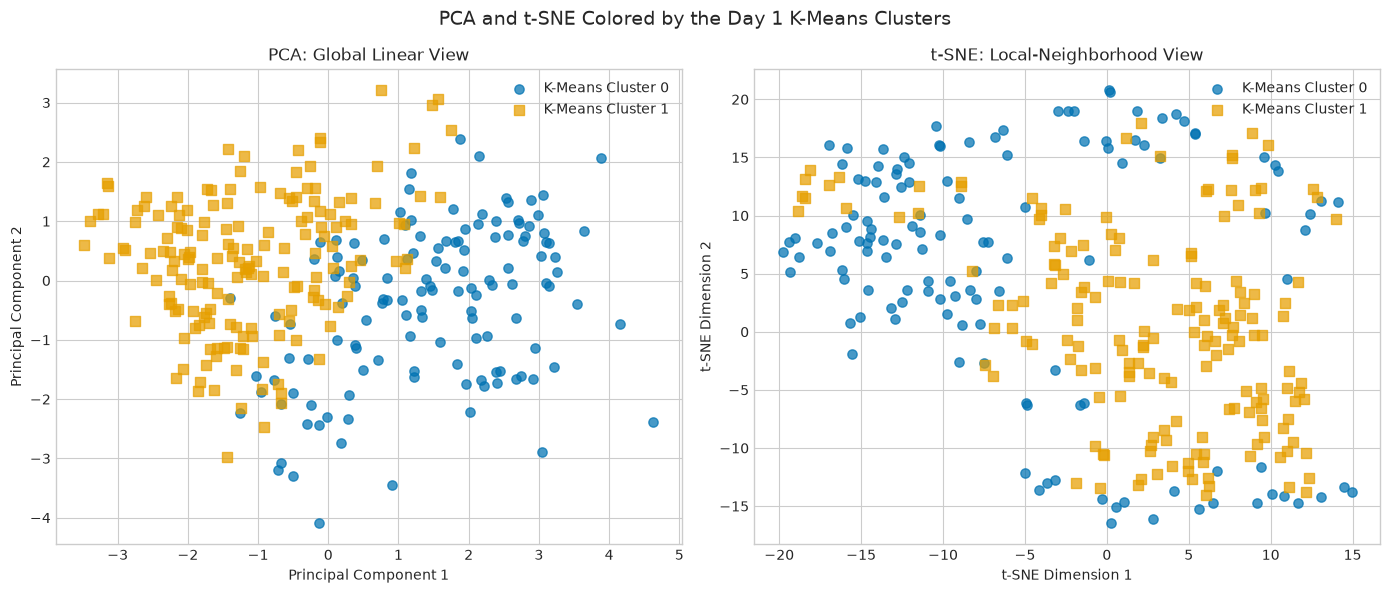

In [7]:
cluster_markers = {
    0: "o",
    1: "s"
}

cluster_colors = {
    0: "#0072B2",
    1: "#E69F00"
}


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


for cluster_id in [0, 1]:
    mask = kmeans_labels == cluster_id

    axes[0].scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        marker=cluster_markers[cluster_id],
        color=cluster_colors[cluster_id],
        label=f"K-Means Cluster {cluster_id}",
        alpha=0.72,
        s=45
    )

    axes[1].scatter(
        X_tsne_2d[mask, 0],
        X_tsne_2d[mask, 1],
        marker=cluster_markers[cluster_id],
        color=cluster_colors[cluster_id],
        label=f"K-Means Cluster {cluster_id}",
        alpha=0.72,
        s=45
    )


axes[0].set_title(
    "PCA: Global Linear View"
)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()


axes[1].set_title(
    "t-SNE: Local-Neighborhood View"
)
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend()


fig.suptitle(
    "PCA and t-SNE Colored by the Day 1 K-Means Clusters",
    fontsize=14
)

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">Interpreting PCA and t-SNE Together</h2>

The PCA and t-SNE plots describe the same 303 patients but preserve different properties.

The PCA view retains only **35.99%** of the standardized variance in two dimensions. It provides a global linear summary, and the two K-Means profiles remain visibly overlapped.

The t-SNE view emphasizes local neighborhoods. Patients assigned to the same K-Means profile appear more locally concentrated in several regions, although the profiles are not perfectly separated.

This is consistent with the earlier K-Means Silhouette Score of **0.232**: the dataset contains broad structure, but not two sharply isolated populations.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
t-SNE makes some local patient organization easier to see, while PCA provides the more transparent global representation. The two methods answer different visualization questions and should not be ranked using visual separation alone.

<span style="color:#E69F00;"><b>Important:</b></span>  
The t-SNE coordinates cannot be interpreted as clinical measurements, and the visualization should not be used as a replacement feature matrix for the predictive model.

<h2 style="color:#0072B2;">Using Diagnosis Only as an Interpretation Reference</h2>

The diagnosis was excluded from every transformation fitted above.

After PCA and t-SNE are complete, the documented diagnosis may be added as a plot color to ask whether the unsupervised geometry has any visible relationship with the known outcome.

This does not change the fitted representation because the labels are introduced only after the coordinates have already been calculated.

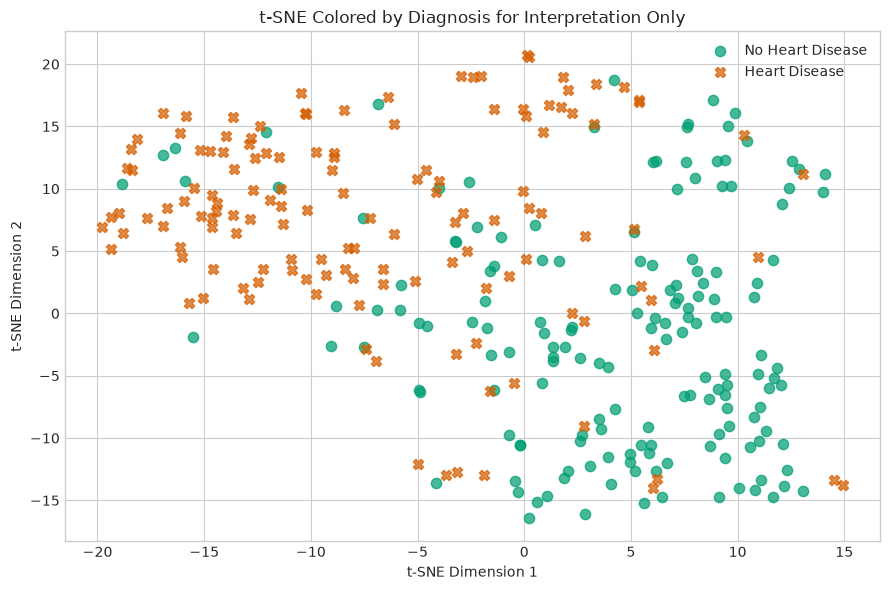

In [8]:
heart_disease = (
    data["num"] > 0
).astype(int)


diagnosis_markers = {
    0: "o",
    1: "X"
}

diagnosis_colors = {
    0: "#009E73",
    1: "#D55E00"
}

diagnosis_names = {
    0: "No Heart Disease",
    1: "Heart Disease"
}


plt.figure(figsize=(9, 6))

for diagnosis in [0, 1]:
    mask = heart_disease.to_numpy() == diagnosis

    plt.scatter(
        X_tsne_2d[mask, 0],
        X_tsne_2d[mask, 1],
        marker=diagnosis_markers[diagnosis],
        color=diagnosis_colors[diagnosis],
        label=diagnosis_names[diagnosis],
        alpha=0.72,
        s=55
    )


plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    "t-SNE Colored by Diagnosis for Interpretation Only"
)
plt.legend()
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">Diagnosis-Reference Interpretation</h2>

The diagnosis-colored t-SNE view shows that heart-disease and no-disease observations are not separated into two pure regions.

Some local areas contain a larger concentration of one reference group, but substantial overlap remains.

This is expected because:

- t-SNE was not trained to separate the diagnosis classes.
- the patient geometry contains continuous and overlapping profiles.
- an unsupervised neighborhood is not equivalent to a diagnostic category.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
Unsupervised structure may be related to the known outcome without reproducing that outcome exactly. Cluster or t-SNE regions must not be renamed as diagnosis classes.

<h2 style="color:#0072B2;">Problem 3 — DBSCAN Noise Is Not the Only Definition of an Anomaly</h2>

Day 2 used local density to identify **18 DBSCAN noise patients**.

Isolation Forest uses a different idea. It repeatedly creates random feature splits and measures how quickly each patient can be isolated.

An unusual patient generally requires fewer random splits to separate from the rest of the population.

<span style="color:#009E73;"><b>Anomaly question:</b></span>  
If Isolation Forest is asked to flag the same number of patients, does it identify the same observations as DBSCAN?

This comparison separates two definitions:

- DBSCAN noise: insufficient local neighborhood density.
- Isolation Forest anomaly: unusually easy to isolate through feature splits.

<h2 style="color:#0072B2;">Choosing the Contamination Value Without Guessing</h2>

The `contamination` parameter tells Isolation Forest what fraction of observations should be flagged.

Day 2 already produced an observed reference:

$$
\text{DBSCAN noise rate}
=
\frac{18}{303}
\approx
5.94\%
$$

For a controlled method comparison, Isolation Forest will be instructed to flag the same proportion.

<span style="color:#009E73;"><b>Decision:</b></span>  
Set contamination to the Day 2 DBSCAN noise proportion. This does not claim that 5.94% is the true medical anomaly rate. It holds the anomaly count approximately constant so that disagreement between the two methods reflects their different definitions rather than different requested group sizes.

In [9]:
contamination_rate = (
    dbscan_noise.sum()
    / len(data)
)


isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


isolation_prediction = isolation_forest.fit_predict(
    X_cluster_scaled
)

isolation_score = isolation_forest.decision_function(
    X_cluster_scaled
)

is_isolation_anomaly = isolation_prediction == -1


print(
    "Contamination used:",
    f"{contamination_rate:.2%}"
)

print(
    "Isolation Forest anomalies:",
    is_isolation_anomaly.sum()
)

Contamination used: 5.94%
Isolation Forest anomalies: 18


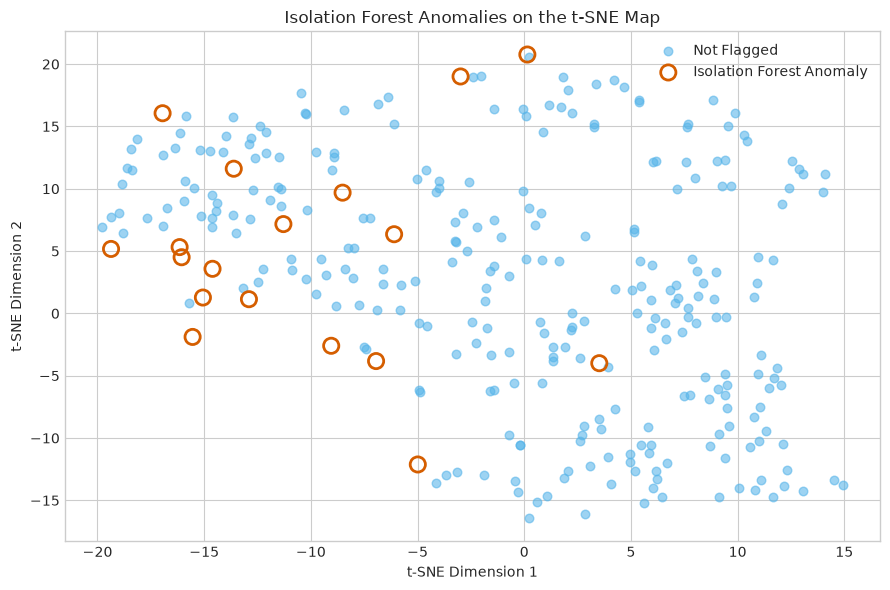

In [10]:
plt.figure(figsize=(9, 6))


plt.scatter(
    X_tsne_2d[~is_isolation_anomaly, 0],
    X_tsne_2d[~is_isolation_anomaly, 1],
    color="#56B4E9",
    marker="o",
    alpha=0.58,
    s=38,
    label="Not Flagged"
)


plt.scatter(
    X_tsne_2d[is_isolation_anomaly, 0],
    X_tsne_2d[is_isolation_anomaly, 1],
    facecolors="none",
    edgecolors="#D55E00",
    marker="o",
    linewidths=2,
    s=120,
    label="Isolation Forest Anomaly"
)


plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    "Isolation Forest Anomalies on the t-SNE Map"
)
plt.legend()
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">Comparing Isolation Forest with DBSCAN Noise</h2>

Because both methods were applied to the same six standardized features and were asked to flag the same number of patients, their overlap can now be measured directly.

The Jaccard similarity between two flagged sets is:

$$
J(A,B)
=
\frac{|A \cap B|}{|A \cup B|}
$$

A value of 1 would mean complete agreement, while 0 would mean no shared flagged patients.

In [11]:
shared_anomalies = (
    dbscan_noise
    & is_isolation_anomaly
)

dbscan_only = (
    dbscan_noise
    & ~is_isolation_anomaly
)

isolation_only = (
    is_isolation_anomaly
    & ~dbscan_noise
)


jaccard_similarity = (
    shared_anomalies.sum()
    / (
        dbscan_noise
        | is_isolation_anomaly
    ).sum()
)


anomaly_comparison = pd.DataFrame({
    "Count": [
        dbscan_noise.sum(),
        is_isolation_anomaly.sum(),
        shared_anomalies.sum(),
        dbscan_only.sum(),
        isolation_only.sum()
    ]
}, index=[
    "DBSCAN Noise",
    "Isolation Forest Anomalies",
    "Flagged by Both",
    "DBSCAN Only",
    "Isolation Forest Only"
])


display(anomaly_comparison)

print(
    "Jaccard similarity:",
    round(jaccard_similarity, 3)
)

,Count
DBSCAN Noise,18
Isolation Forest Anomalies,18
Flagged by Both,12
DBSCAN Only,6
Isolation Forest Only,6


Jaccard similarity: 0.5


<h2 style="color:#0072B2;">Interpreting the Anomaly-Method Comparison</h2>

Both methods flagged 18 patients, but they agreed on only **12** observations.

- 6 patients were flagged only by DBSCAN.
- 6 patients were flagged only by Isolation Forest.
- The Jaccard similarity was **0.500**.

This partial agreement is meaningful. The methods are detecting related but non-identical forms of unusualness.

DBSCAN focuses on whether a patient has enough nearby neighbors. Isolation Forest focuses on whether the patient's feature combination can be separated quickly through random splits.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
Anomaly detection does not produce one universal correct list. The flagged observations depend on how the algorithm defines unusual structure.

<span style="color:#E69F00;"><b>Important:</b></span>  
An anomaly label is not evidence of a data error or a medical diagnosis. It identifies a record that deserves inspection.

<h2 style="color:#0072B2;">Inspecting Two Strongly Flagged Patients</h2>

The Isolation Forest decision score measures how normal or unusual each observation appears under the fitted model.

Lower scores indicate stronger anomaly evidence.

The two patients with the lowest scores will be inspected using:

- Their original clinical measurements.
- Their absolute standardized values across the six anomaly features.

An absolute standardized value indicates how far a measurement lies from the feature mean in standard-deviation units.

In [12]:
anomaly_audit = X_cluster_imputed.copy()

anomaly_audit["Diagnosis Reference"] = np.where(
    heart_disease == 1,
    "Heart Disease",
    "No Heart Disease"
)

anomaly_audit["K-Means Cluster"] = kmeans_labels
anomaly_audit["DBSCAN Noise"] = dbscan_noise
anomaly_audit["Isolation Score"] = isolation_score
anomaly_audit["Isolation Anomaly"] = is_isolation_anomaly


two_strongest_anomalies = (
    anomaly_audit[
        anomaly_audit["Isolation Anomaly"]
    ]
    .nsmallest(
        2,
        "Isolation Score"
    )
)


display(two_strongest_anomalies.round(3))

,age,trestbps,chol,thalach,oldpeak,ca,Diagnosis Reference,K-Means Cluster,DBSCAN Noise,Isolation Score,Isolation Anomaly
91,62.0,160.0,164.0,145.0,6.2,3.0,Heart Disease,0,True,-0.108,True
121,63.0,150.0,407.0,154.0,4.0,3.0,Heart Disease,0,True,-0.074,True


In [13]:
for patient_index in two_strongest_anomalies.index:

    absolute_standardized_values = (
        X_cluster_scaled
        .loc[patient_index]
        .abs()
        .sort_values(ascending=False)
    )

    patient_explanation = pd.DataFrame({
        "Original Value": (
            X_cluster_imputed
            .loc[patient_index]
        ),
        "Absolute Standardized Value": (
            absolute_standardized_values
        )
    }).sort_values(
        "Absolute Standardized Value",
        ascending=False
    )

    print(
        f"Patient index: {patient_index}"
    )

    display(
        patient_explanation.round(3)
    )

Patient index: 91


,Original Value,Absolute Standardized Value
oldpeak,6.2,4.452
ca,3.0,2.505
trestbps,160.0,1.611
chol,164.0,1.600
age,62.0,0.838
thalach,145.0,0.202


Patient index: 121


,Original Value,Absolute Standardized Value
chol,407.0,3.101
oldpeak,4.0,2.554
ca,3.0,2.505
trestbps,150.0,1.042
age,63.0,0.949
thalach,154.0,0.192


<h2 style="color:#0072B2;">Interpreting the Two Inspected Patients</h2>

### Patient index 91

This patient received the lowest Isolation Forest score.

The strongest unusual measurements were:

- `oldpeak = 6.2`, approximately 4.45 standard deviations from the mean.
- `ca = 3`, approximately 2.50 standard deviations from the mean.
- Resting blood pressure was also above the mean, while cholesterol was unusually low relative to the dataset.

The patient was also flagged as DBSCAN noise, showing agreement between the isolation-based and local-density definitions.

### Patient index 121

This patient also showed several simultaneous extreme measurements:

- `chol = 407`, approximately 3.10 standard deviations from the mean.
- `oldpeak = 4.0`, approximately 2.55 standard deviations from the mean.
- `ca = 3`, approximately 2.50 standard deviations from the mean.

This patient was also flagged by DBSCAN.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
Isolation Forest did not flag these patients because of one predetermined medical threshold. It identified unusual multivariable combinations in the six-dimensional standardized feature space.

<span style="color:#D55E00;"><b>Safety limitation:</b></span>  
The findings describe statistical unusualness only. They do not establish that either record is incorrect, clinically dangerous, or diagnostically unique.

<h2 style="color:#0072B2;">Day 4 Conclusion</h2>

This notebook extended the same Cleveland patient-structure analysis from Days 1–3.

### t-SNE findings

- PCA and t-SNE were fitted using the same 13-feature standardized representation.
- PCA provided a global linear view whose first two components retained **35.99%** of standardized variance.
- t-SNE emphasized local neighborhoods and made parts of the broad K-Means structure easier to inspect visually.
- Considerable overlap remained, consistent with the modest Day 1 K-Means Silhouette Score of **0.232**.
- Diagnosis-colored plots were used only after fitting and did not convert the analysis into supervised learning.

### Anomaly-detection findings

- Isolation Forest was applied to the same six-feature representation used for Day 2 DBSCAN.
- Its contamination value matched the observed DBSCAN noise rate: $18/303 \approx 5.94\%$.
- Both methods flagged 18 patients.
- They agreed on 12, while each method uniquely flagged 6.
- Their Jaccard similarity was **0.500**, showing partial rather than complete agreement.
- Inspection of two strongly flagged patients showed unusual combinations involving `oldpeak`, `ca`, cholesterol, and resting blood pressure.

<span style="color:#009E73;"><b>Final lesson:</b></span>  
PCA and t-SNE reveal different aspects of patient geometry, while DBSCAN and Isolation Forest apply different definitions of unusualness. These tools complement each other rather than producing one universally correct representation.

<span style="color:#D55E00;"><b>Final interpretation rule:</b></span>  
Clusters, t-SNE regions, DBSCAN noise, and Isolation Forest anomalies are statistical findings. None should be presented as a diagnosis without external clinical validation.